# Lista 4 - Redes Neurais Artificiais

## Questão 1

Considere o conjunto de dados disponível em **concrete.csv**, organizado em 9 colunas, sendo as 8 primeiras colunas os atributos e a última coluna a saída. Os 8 atributos referem-se à caracterização de diferentes tipos de concreto para construção civil. A saída é a resistência à compressão do concreto (em megapascals, MPa).

a) Considere um modelo de regressão não linear baseado em redes neurais artificiais. Separe os dados aleatoriamente em treino, validação e teste (por exemplo, 60%, 20% e 20%). Nesse cenário, treine e avalie o modelo abaixo:

- **MLP (multilayer perceptron):** 1 camada oculta e treinamento em *minibatch* via gradiente descendente estocástico com termo de *momentum*. Utilize o conjunto de validação para ajustar os hiperparâmetros.

### **Solução**

In [1]:
import sys
sys.path.append("../")

In [2]:
# 1. Importação das bibliotecas necessárias
from utils.utils import *
from preprocessors.normalizador import Normalizador
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
import matplotlib.pyplot as plt

In [3]:
# 2. Extração dos dados
X = concrete[:, :-1]
y = concrete[:, [-1]]

In [4]:
# 3. Divisão dos dados nos conjuntos de treino, validação e teste
X_train, X_val, X_test, y_train, y_val, y_test = treine_valide_teste_divida(X, y)

In [5]:
# 4. Normalização dos dados de treinamento via MinMaxScaler
X_train_normalizer = Normalizador(X_train)
y_train_normalizer = Normalizador(y_train)
X_train_transformed = X_train_normalizer.normaliza(X_train)
y_train_transformed = y_train_normalizer.normaliza(y_train)

In [6]:
X_val_transformed = X_train_normalizer.normaliza(X_val)

In [7]:
#5. Otimização dos hiperparâmetros via grid search
funcao_de_ativacao = ["tanh", "relu", "logistic"]
alpha = [0.0001, 0.001, 0.00001, 0.01]
batch_size = [1, 16, 32, 100, 200]

best_score = 0

for func in funcao_de_ativacao:
        for a in alpha:
            for b in batch_size:
                regressorMLP = MLPRegressor(1, func, solver="sgd", momentum=0.9, alpha=a, batch_size=b, random_state=42, shuffle=True)
                regressorMLP.fit(X_train_transformed, y_train_transformed)
                y_pred = regressorMLP.predict(X_val_transformed)
                y_pred = y_train_normalizer.desnormaliza(y_pred)
                rmse = np.sqrt(mean_squared_error(y_val, y_pred))
                if rmse > best_score:
                    best_score = rmse
                    params = regressorMLP.get_params()
                    

c:\Users\Suporte\anaconda3\envs\ICD\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:1625: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\Suporte\anaconda3\envs\ICD\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:1625: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\Suporte\anaconda3\envs\ICD\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:1625: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\Suporte\anaconda3\envs\ICD\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:162

In [8]:
print(f"Melhor score: {best_score}")
print("Hiperparâmtros otimizados:")
print(params)

Melhor score: 18.53259285224159
Hiperparâmtros otimizados:
{'activation': 'relu', 'alpha': 1e-05, 'batch_size': 200, 'beta_1': 0.9, 'beta_2': 0.999, 'early_stopping': False, 'epsilon': 1e-08, 'hidden_layer_sizes': 1, 'learning_rate': 'constant', 'learning_rate_init': 0.001, 'max_fun': 15000, 'max_iter': 200, 'momentum': 0.9, 'n_iter_no_change': 10, 'nesterovs_momentum': True, 'power_t': 0.5, 'random_state': 42, 'shuffle': True, 'solver': 'sgd', 'tol': 0.0001, 'validation_fraction': 0.1, 'verbose': False, 'warm_start': False}


###
b) Apresente as curvas da função custo nos conjuntos de treinamento e validação ao longo das épocas. Reporte também para os conjuntos de treino, validação e teste as métricas abaixo:

* **RMSE (root mean squared error):** $\sqrt{\frac{1}{N}\sum_i(y_i - \hat{y}_i)^2}$;
* **MAE (mean absolute error):** $\frac{1}{N}\sum_i |y_i - \hat{y}_i|$;
* **MRE (mean relative error):** $\frac{1}{N}\sum_i\left|\frac{y_i-\hat{y}_i}{y_i}\right|$.

### **Solução**

In [9]:
# 6. Treinamento do modelo com os conjuntos de treinamento e validação
X_train_val = np.vstack([X_train, X_val])
y_train_val = np.vstack([y_train, y_val])
X_train_val_transformed = X_train_normalizer.normaliza(X_train_val)
y_train_val_transformed = y_train_normalizer.normaliza(y_train_val)

regressorMLP = MLPRegressor(**params)
regressorMLP.fit(X_train_val_transformed, y_train_val_transformed)

c:\Users\Suporte\anaconda3\envs\ICD\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:1625: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


MLPRegressor(alpha=1e-05, batch_size=200, hidden_layer_sizes=1, random_state=42,
             solver='sgd')

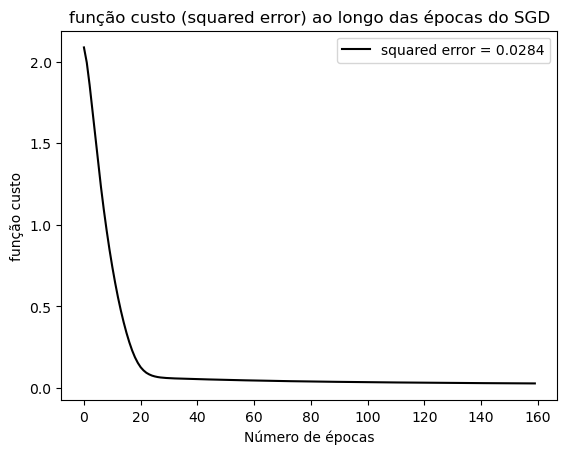

In [14]:
# 7. Visualização da função custo ao longo das épocas
loss = regressorMLP.loss_
y_loss = regressorMLP.loss_curve_
x_loss = np.arange(0, len(y_loss))
plt.plot(x_loss, y_loss, color="black", label=f"squared error = {loss:.4f}")
plt.title("função custo (squared error) ao longo das épocas do SGD")
plt.legend()
plt.ylabel("função custo")
plt.xlabel("Número de épocas")
plt.show()

In [15]:
# 8. Reporte das métricas
y_pred = regressorMLP.predict(X_train_val_transformed)
y_pred = y_train_normalizer.desnormaliza(y_pred)

print("====================== Métricas do treinamento/validação ======================")
print(f"RMSE = {np.sqrt(mean_absolute_error(y_train_val, y_pred))}")
print(f"MAE = {mean_absolute_error(y_train_val, y_pred)}")
print(f"MRE = {mean_absolute_percentage_error(y_train_val, y_pred)}")

X_test_transformed = X_train_normalizer.normaliza(X_test)
y_pred = regressorMLP.predict(X_test_transformed)
y_pred = y_train_normalizer.desnormaliza(y_pred)

print("====================== Métricas do teste ======================")
print(f"RMSE = {np.sqrt(mean_absolute_error(y_test, y_pred))}")
print(f"MAE = {mean_absolute_error(y_test, y_pred)}")
print(f"MRE = {mean_absolute_percentage_error(y_test, y_pred)}")

====================== Métricas do treinamento/validação ======================
RMSE = 3.8782580763893937
MAE = 15.040885707079559
MRE = 0.5758718386347136
====================== Métricas do teste ======================
RMSE = 3.872075496810263
MAE = 14.992968652998442
MRE = 0.5617513742092554


## Questão 2

Considere o conjunto de dados disponível em **vowel.csv**, organizado em 11 colunas, sendo as 10 primeiras colunas os atributos e a última coluna a saída. Os 10 atributos referem-se à caracterização de amostras da fala de britânicos. A saída é o fonema de vogal correspondente, dentre as 11 possibilidades.

a) Considere um modelo de classificação não linear baseado em redes neurais artificiais. Separe os dados aleatoriamente em treino, validação e teste (por exemplo, 60%, 20% e 20%). Nesse cenário, treine e avalie o modelo abaixo:

- **MLP (multilayer perceptron):** 1 camada oculta e treinamento em *minibatch* via gradiente descendente estocástico com termo de *momentum*. Utilize o conjunto de validação para ajustar os hiperparâmetros.

### **Solução**

In [7]:
# 1. Importação das bibliotecas necessárias
from utils.utils import *
from preprocessors.normalizador import Normalizador
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

In [8]:
# 2. Extração dos dados
X = vowel[:, :-1]
y = vowel[:, [-1]]

In [9]:
# 3. Divisão dos dados nos conjuntos de treino, validação e teste
X_train, X_val, X_test, y_train, y_val, y_test = treine_valide_teste_divida(X, y)

In [4]:
# 4. Normalização dos dados de treinamento via z-score
X_train_normalizer = Normalizador(X_train, method="StandardScaler")
X_train_transformed = X_train_normalizer.normaliza(X_train)
X_val_transformed = X_train_normalizer.normaliza(X_val)

y_train_encoded = one_hot_encoding(y_train, 11)
y_val_encoded = one_hot_encoding(y_val, 11)
y_test_encoded = one_hot_encoding(y_test, 11)

In [19]:
#5. Otimização dos hiperparâmetros via grid search
funcao_de_ativacao = ["tanh", "relu", "logistic"]
alpha = [0.0001, 0.001, 0.00001, 0.01]
batch_size = [1, 16, 32, 100, 200]

best_acc = 0

for func in funcao_de_ativacao:
        for a in alpha:
            for b in batch_size:
                classificadorMLP = MLPClassifier(1, func, solver="sgd", momentum=0.9, alpha=a, batch_size=b, random_state=42, shuffle=True, max_iter=100000)
                classificadorMLP.fit(X_train_transformed, y_train_encoded)
                y_pred = classificadorMLP.predict(X_val_transformed)
                acc = accuracy_score(y_val_encoded.argmax(axis=1).reshape(-1,1), y_pred.argmax(axis=1).reshape(-1,1))
                if acc > best_acc:
                    best_acc = acc
                    params = classificadorMLP.get_params()
                    

In [20]:
print(f"Melhor acurácia: {best_acc}")
print("Hiperparâmtros otimizados:")
print(params)

Melhor acurácia: 0.09595959595959595
Hiperparâmtros otimizados:
{'activation': 'relu', 'alpha': 0.0001, 'batch_size': 200, 'beta_1': 0.9, 'beta_2': 0.999, 'early_stopping': False, 'epsilon': 1e-08, 'hidden_layer_sizes': 1, 'learning_rate': 'constant', 'learning_rate_init': 0.001, 'max_fun': 15000, 'max_iter': 100000, 'momentum': 0.9, 'n_iter_no_change': 10, 'nesterovs_momentum': True, 'power_t': 0.5, 'random_state': 42, 'shuffle': True, 'solver': 'sgd', 'tol': 0.0001, 'validation_fraction': 0.1, 'verbose': False, 'warm_start': False}


###
b) Apresente as curvas da função custo nos conjuntos de treinamento e validação ao longo das épocas. Reporte também a acurácia obtida para os conjuntos de treino, validação e teste.

### **Solução**

In [21]:
# 6. Treinamento do modelo com os conjuntos de treinamento e validação
X_train_val = np.vstack([X_train, X_val])
y_train_val = np.vstack([y_train, y_val])
X_train_val_transformed = X_train_normalizer.normaliza(X_train_val)

classificadorMLP = MLPClassifier(**params)
classificadorMLP.fit(X_train_val_transformed, y_train_val)

c:\Users\Suporte\anaconda3\envs\ICD\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:1102: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


MLPClassifier(batch_size=200, hidden_layer_sizes=1, max_iter=100000,
              random_state=42, solver='sgd')

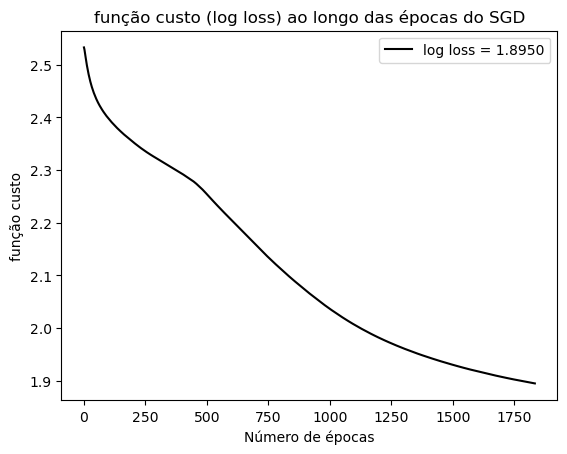

In [22]:
# 7. Visualização da função custo ao longo das épocas
loss = classificadorMLP.loss_
y_loss = classificadorMLP.loss_curve_
x_loss = np.arange(0, len(y_loss))
plt.plot(x_loss, y_loss, color="black", label=f"log loss = {loss:.4f}")
plt.title("função custo (log loss) ao longo das épocas do SGD")
plt.legend()
plt.ylabel("função custo")
plt.xlabel("Número de épocas")
plt.show()

In [66]:
# 8. Reporte das métricas
y_pred = classificadorMLP.predict(X_train_val_transformed)

print("====================== Métricas do treinamento/validação ======================")
print(f"Acurácia = {accuracy_score(y_train_val, y_pred)}")

X_test_transformed = X_train_normalizer.normaliza(X_test)
y_pred = classificadorMLP.predict(X_test_transformed)

print("====================== Métricas do teste ======================")
print(f"Acurácia = {accuracy_score(y_test, y_pred)}")

====================== Métricas do treinamento/validação ======================
Acurácia = 0.2638888888888889
====================== Métricas do teste ======================
Acurácia = 0.26262626262626265
